# Predição de Ações do Banco do Brasil (BBAS3) com MLP
Este notebook demonstra um fluxo de regressão para prever o preço de fechamento das ações utilizando redes neurais simples.

## Bibliotecas

In [ ]:
!pip install yfinance

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Obtenção dos Dados

In [3]:
def baixar_dados_acao(ticker, inicio, fim):
    dados = yf.download(ticker, start=inicio, end=fim)
    return dados

ticker_bb = 'BBAS3.SA'
dados_banco_brasil = baixar_dados_acao(ticker_bb, '2020-01-01', '2023-12-31')
display(dados_banco_brasil.head())

/tmp/ipykernel_13891/1216561099.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dados = yf.download(ticker, start=inicio, end=fim)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,BBAS3.SA,BBAS3.SA,BBAS3.SA,BBAS3.SA,BBAS3.SA
Date,,,,,
2020-01-02,17.015818,17.069586,16.816561,16.873492,26319800
2020-01-03,16.987347,17.050603,16.715346,16.794416,18930800
2020-01-06,16.762789,16.889301,16.588836,16.889301,19999800
2020-01-07,16.636278,16.772278,16.538232,16.762790,21277000
2020-01-08,16.484467,16.759630,16.459165,16.686885,42937200


## Preparação dos Dados

In [4]:
def preparar_dados_regressao(dados, janela=5):
    df = dados[['Close']].copy()
    for i in range(1, janela + 1):
        df[f'fechamento_atraso_{i}'] = df['Close'].shift(i)

    df.dropna(inplace=True)
    X = df.drop(columns=['Close'])
    y = df['Close']
    return X, y

caracteristicas, alvo = preparar_dados_regressao(dados_banco_brasil)

# Divisão entre treino (80%) e teste (20%)
X_treino, X_teste, y_treino, y_teste = train_test_split(
    caracteristicas, alvo, test_size=0.2, shuffle=False
)

# Normalização
padronizador = StandardScaler()
X_treino_escalonado = padronizador.fit_transform(X_treino)
X_teste_escalonado = padronizador.transform(X_teste)

## Modelo MLP

In [5]:
modelo_tf = Sequential([
        Dense(100, activation='relu', input_dim=X_treino_escalonado.shape[1]),
        Dense(50, activation='relu'),
        Dense(1) # Camada de saída para regressão
    ])

modelo_tf.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Treinamento

In [6]:
historico = modelo_tf.fit(
    X_treino_escalonado, y_treino,
    epochs=100,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 125.8124 - val_loss: 158.9290
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 87.2371 - val_loss: 75.4554
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 41.2544 - val_loss: 21.2285
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 27.7176 - val_loss: 22.1733
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 24.5008 - val_loss: 18.4442
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 20.9315 - val_loss: 15.9283
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 16.4972 - val_loss: 12.6876
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 11.7131 - val_loss: 8.8702
Epoch 9/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 7.8116 - val_loss: 6.9958
Epoch 10/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 4.7754 - val_loss: 3.7698
Epoch 11/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 2.8003 - val_loss: 3.0705
Epoch 12/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s

## Predição

In [7]:
predicoes = modelo_tf.predict(X_teste_escalonado).flatten()

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


# Métricas de avaliação

In [8]:
erro_medio_absoluto = mean_absolute_error(y_teste, predicoes)
erro_quadratico_medio = mean_squared_error(y_teste, predicoes)
coeficiente_r2 = r2_score(y_teste, predicoes)

print(f"Métricas de Regressão:")
print(f"MAE: {erro_medio_absoluto:.2f}")
print(f"MSE: {erro_quadratico_medio:.2f}")
print(f"R² Score: {coeficiente_r2:.4f}")


Métricas de Regressão:
MAE: 0.45
MSE: 0.34
R² Score: 0.9239


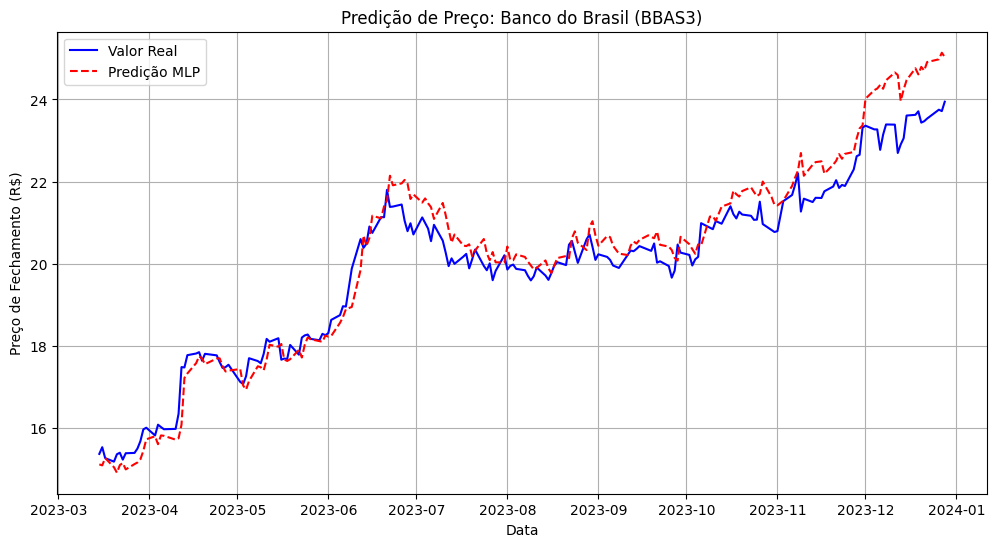

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(y_teste.index, y_teste.values, label='Valor Real', color='blue')
plt.plot(y_teste.index, predicoes, label='Predição MLP', color='red', linestyle='--')
plt.title('Predição de Preço: Banco do Brasil (BBAS3)')
plt.xlabel('Data')
plt.ylabel('Preço de Fechamento (R$)')
plt.legend()
plt.grid(True)
plt.show()